<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_6_Extracting_Information_from_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Extracting Information from Text (NER with spaCy)


## Task 1: Import Necessary Libraries

In [1]:
# Installing required libraries
!pip install spacy beautifulsoup4 lxml

# Downloading the spaCy model
!python -m spacy download en_core_web_sm

# Importing libraries
import spacy
from bs4 import BeautifulSoup
import json
import pandas as pd
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 90.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Task 2: Load and Preprocess the Text Data

In [2]:
# Uploading the  XML file in Colab
from google.colab import files
uploaded = files.upload()

# Getting file name
file_name = list(uploaded.keys())[0]

# Reading the XML file
with open(file_name, 'r', encoding='utf-8') as file:
    xml_data = file.read()

# Parse XML using BeautifulSoup
soup = BeautifulSoup(xml_data, 'lxml')

# Extracting transcription text
transcription_div = soup.find('div', {'type': 'transcription'})
text = transcription_div.get_text(separator=' ', strip=True)

# Cleaning text (replaceing & with 'and')
cleaned_text = text.replace('&', 'and')

print(cleaned_text[:1000])  # preview

Saving letters_152.xml to letters_152.xml
I am ashamed that I have never before acknowledged the receipt of the very valuable packet of specimens you were so kind as to send me. Having now got my plants up from Cheshire I shall lose no time in making up a parcel for you. By some mistake the packet containing my Irish plants is not with the rest. Of these the only really rare ones are Arbutus unedo, Stachys ambigua and Trichomanes brevisetum. The first and last I gathered with Wilson so you have perhaps already received them from him but the other I think he did not find. I shall therefore if they do not arrive in time for this parcel enclose them in another before the season is over as there are some of your desiderata of which I have no duplicates by me but which I can easily procure in the ensuing Spring and Summer. In sending you parcels I shall not conform myself strictly to your desiderata but send you duplicates of rare or local plants which if you already possess you can give to

/tmp/ipykernel_21695/1754856271.py:13: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(xml_data, 'lxml')


# Task 3: Perform Named Entity Recognition (NER)

In [3]:
# Loading the spaCy model
nlp = spacy.load("en_core_web_sm")

# Process text
doc = nlp(cleaned_text)

# Extracting the entities
entities = [(ent.text, ent.label_) for ent in doc.ents]

# Displaying the entities
for ent in entities:
    print(ent)

('Cheshire', 'PERSON')
('Irish', 'NORP')
('Arbutus', 'ORG')
('Stachys', 'GPE')
('Trichomanes', 'NORP')
('first', 'ORDINAL')
('Wilson', 'PERSON')
('Spring', 'DATE')
('Summer', 'DATE')
('Wilson', 'ORG')
('a few days ago', 'DATE')
('the Rev d G E Smith', 'ORG')
('Cyperus', 'ORG')
('Orobanche', 'ORG')
('Arnott', 'PERSON')
('M r Bentham', 'ORG')
('South', 'LOC')
('France', 'GPE')
('Pyrenees', 'GPE')
('Europe', 'LOC')
('British', 'NORP')
('Cambridge', 'GPE')
('Edinburgh', 'GPE')
('G A Walker Arnott Esq', 'ORG')
('Advocate', 'GPE')
('7 S', 'CARDINAL')
('John Street Edinburgh', 'FAC')
('Botanic Garden', 'LOC')
('one', 'CARDINAL')
('Noyau', 'ORG')
('Ipomea or Convolvulus', 'ORG')


# Task 4: Analyze Named Entity Recognition Results

Label
ORG         9
GPE         6
PERSON      3
NORP        3
DATE        3
LOC         3
CARDINAL    2
ORDINAL     1
FAC         1
Name: count, dtype: int64


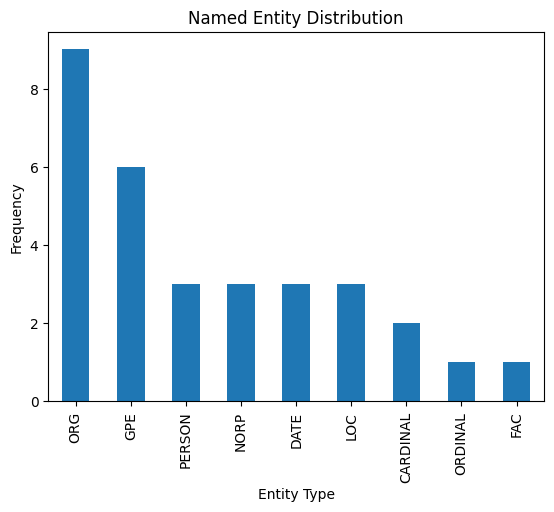

In [4]:
# Creating DataFrame
df = pd.DataFrame(entities, columns=['Entity', 'Label'])

# Frequency distribution
freq = df['Label'].value_counts()

print(freq)

# Plotting bar chart
freq.plot(kind='bar')
plt.title("Named Entity Distribution")
plt.xlabel("Entity Type")
plt.ylabel("Frequency")
plt.show()

# Task 5: Save and Document the Results

In [5]:
# Saving entities to JSON
with open("ner_results.json", "w") as f:
    json.dump(entities, f)

# Saving to CSV
df.to_csv("ner_results.csv", index=False)

print("Files saved: ner_results.json and ner_results.csv")

Files saved: ner_results.json and ner_results.csv


# Task 6: Visualize Named Entities with displaCy

*   List item
*   List item



In [7]:
from spacy import displacy

# Rendering in notebook
displacy.render(doc, style='ent', jupyter=True)

# Saving as HTML
html = displacy.render(doc, style='ent')
with open("ner_visualization.html", "w") as f:
    f.write(html)

print("Visualization saved as ner_visualization.html")

TypeError: write() argument must be str, not None